# Framewise Displacement Analysis for fMRIPrep Data

This notebook analyzes framewise displacement (FD) from fMRIPrep confounds files,
creates visualization plots, and integrates the results into HTML reports for QA.

## Define Variables and Setup

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import base64
from io import BytesIO
from bs4 import BeautifulSoup
import glob
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION VARIABLES - MODIFY THESE AS NEEDED
# =============================================================================

# Subject ID - use 'all' to process all subjects, or specify like 'GR037'
SUBJECT = 'GEO037'  # Options: 'all', 'GR037', 'GR038', etc.

# Framewise Displacement threshold in mm
FD_LIMIT = 0.75

# Derivatives type - affects which confounds file to use
DERIVATIVES_TYPE = 'nocorrection'  # Options: 'default', 'nocorrection', 'noSDC'

# Path to your BIDS derivatives directory
DERIVATIVES_DIR = '/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection'  # UPDATE THIS PATH

# Optional filters (leave as None to process all)
SESSION_FILTER = None  # e.g., '01' or None for all sessions
TASK_FILTER = None     # e.g., 'rest' or None for all tasks
RUN_FILTER = None      # e.g., '01' or None for all runs

# Plot settings
PLOT_WIDTH = 12
PLOT_HEIGHT = 6
PLOT_DPI = 150

print("Configuration loaded:")
print(f"Subject: {SUBJECT}")
print(f"FD Threshold: {FD_LIMIT} mm")
print(f"Derivatives Type: {DERIVATIVES_TYPE}")
print(f"Derivatives Directory: {DERIVATIVES_DIR}")

Configuration loaded:
Subject: GEO037
FD Threshold: 0.75 mm
Derivatives Type: nocorrection
Derivatives Directory: /data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection


## Helper Functions

In [13]:
def get_confounds_filename_pattern(derivatives_type):
    """Get the appropriate confounds filename pattern based on derivatives type"""
    patterns = {
        'default': '*desc-confounds_timeseries.tsv',
        'nocorrection': '*desc-confounds_timeseries.tsv',  # Same file, different processing
        'noSDC': '*desc-confounds_timeseries.tsv'  # Same file, different processing
    }
    return patterns.get(derivatives_type, '*desc-confounds_timeseries.tsv')

def find_subjects(derivatives_dir, subject_filter):
    """Find subjects to process based on filter"""
    fmriprep_dir = Path(derivatives_dir)
    
    if subject_filter.lower() == 'all':
        # Find all subject directories
        subject_dirs = list(fmriprep_dir.glob('sub-*'))
        subjects = [d.name[4:] for d in subject_dirs if d.is_dir()]  # Remove 'sub-' prefix
        print(f"Found {len(subjects)} subjects: {subjects}")
    else:
        subjects = [subject_filter]
        subject_dir = fmriprep_dir / f'sub-{subject_filter}'
        if not subject_dir.exists():
            raise FileNotFoundError(f"Subject directory not found: {subject_dir}")
        print(f"Processing single subject: {subject_filter}")
    
    return subjects

def find_confounds_files(derivatives_dir, subject_id, derivatives_type, 
                        session_filter=None, task_filter=None, run_filter=None):
    """Find confounds files for a subject with optional filters"""
    fmriprep_dir = Path(derivatives_dir)
    subject_dir = fmriprep_dir / f'sub-{subject_id}'
    
    # Build search pattern
    search_pattern = f'sub-{subject_id}'
    if session_filter:
        search_pattern += f'_ses-{session_filter}'
    if task_filter:
        search_pattern += f'_task-{task_filter}'
    if run_filter:
        search_pattern += f'_run-{run_filter}'
    
    pattern_suffix = get_confounds_filename_pattern(derivatives_type)
    search_pattern += pattern_suffix
    
    confounds_files = list(subject_dir.rglob(search_pattern))
    return confounds_files

def parse_filename_identifiers(filename):
    """Extract subject, session, task, run from filename"""
    parts = Path(filename).name.replace('.tsv', '').split('_')
    
    identifiers = {}
    for part in parts:
        if part.startswith('sub-'):
            identifiers['subject'] = part[4:]
        elif part.startswith('ses-'):
            identifiers['session'] = part[4:]
        elif part.startswith('task-'):
            identifiers['task'] = part[5:]
        elif part.startswith('run-'):
            identifiers['run'] = part[4:]
    
    return identifiers

print("Helper functions defined successfully!")

Helper functions defined successfully!


## Open Confounds Files and Load Data

In [14]:
subjects_to_process = find_subjects(DERIVATIVES_DIR, SUBJECT)

# Dictionary to store all confounds data
all_confounds_data = {}

print("Loading confounds files...")
print("=" * 50)

for subject_id in subjects_to_process:
    print(f"\nProcessing subject: {subject_id}")
    
    # Find confounds files for this subject
    confounds_files = find_confounds_files(
        DERIVATIVES_DIR, subject_id, DERIVATIVES_TYPE,
        SESSION_FILTER, TASK_FILTER, RUN_FILTER
    )
    
    if not confounds_files:
        print(f"  No confounds files found for subject {subject_id}")
        continue
    
    print(f"  Found {len(confounds_files)} confounds files")
    
    # Load each confounds file
    subject_data = {}
    
    for confounds_file in confounds_files:
        try:
            # Parse identifiers from filename
            identifiers = parse_filename_identifiers(confounds_file)
            
            # Create unique key for this run
            key_parts = [f"sub-{identifiers.get('subject', 'unknown')}"]
            if 'session' in identifiers:
                key_parts.append(f"ses-{identifiers['session']}")
            if 'task' in identifiers:
                key_parts.append(f"task-{identifiers['task']}")
            if 'run' in identifiers:
                key_parts.append(f"run-{identifiers['run']}")
            
            run_key = "_".join(key_parts)
            
            # Load confounds data
            confounds_df = pd.read_csv(confounds_file, sep='\t')
            
            # Check if framewise_displacement exists
            if 'framewise_displacement' not in confounds_df.columns:
                print(f"    WARNING: No framewise_displacement in {confounds_file.name}")
                continue
            
            # Store data
            subject_data[run_key] = {
                'confounds_df': confounds_df,
                'confounds_file': confounds_file,
                'identifiers': identifiers,
                'fd_data': confounds_df['framewise_displacement'].dropna()
            }
            
            print(f"    Loaded: {run_key}")
            print(f"      Volumes: {len(confounds_df)}")
            print(f"      FD values: {len(subject_data[run_key]['fd_data'])}")
            
        except Exception as e:
            print(f"    ERROR loading {confounds_file.name}: {e}")
    
    all_confounds_data[subject_id] = subject_data

print("\n" + "=" * 50)
print(f"Data loading complete!")
print(f"Loaded data for {len(all_confounds_data)} subjects")

# Display summary
for subject_id, subject_data in all_confounds_data.items():
    print(f"\nSubject {subject_id}: {len(subject_data)} runs loaded")

Processing single subject: GEO037
Loading confounds files...

Processing subject: GEO037
  Found 11 confounds files
    Loaded: sub-GEO037_ses-t2_task-image_run-1
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t2_task-image_run-2
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t2_task-image_run-3
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t2_task-image_run-4
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t2_task-image_run-5
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t3_task-image_run-1
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t3_task-image_run-2
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t3_task-image_run-3
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t3_task-image_run-4
      Volumes: 395
      FD values: 394
    Loaded: sub-GEO037_ses-t3_task-image_run-5
      Volumes: 395
      FD values: 394
    Loaded: su

## Calculate FD Statistics and Percentages

In [15]:
# Dictionary to store FD analysis results
fd_analysis_results = {}

print("Analyzing Framewise Displacement...")
print("=" * 50)
print(f"Using FD threshold: {FD_LIMIT} mm")

for subject_id, subject_data in all_confounds_data.items():
    print(f"\nSubject: {subject_id}")
    subject_results = {}
    
    for run_key, run_data in subject_data.items():
        fd_data = run_data['fd_data']
        
        if len(fd_data) == 0:
            print(f"  {run_key}: No FD data available")
            continue
        
        # Calculate statistics
        high_motion_mask = fd_data > FD_LIMIT
        n_high_motion = high_motion_mask.sum()
        total_volumes = len(fd_data)
        percentage_high_motion = (n_high_motion / total_volumes) * 100
        
        # Calculate additional statistics
        mean_fd = fd_data.mean()
        median_fd = fd_data.median()
        max_fd = fd_data.max()
        std_fd = fd_data.std()
        
        # Store results
        results = {
            'fd_data': fd_data,
            'high_motion_mask': high_motion_mask,
            'n_high_motion': n_high_motion,
            'total_volumes': total_volumes,
            'percentage_high_motion': percentage_high_motion,
            'mean_fd': mean_fd,
            'median_fd': median_fd,
            'max_fd': max_fd,
            'std_fd': std_fd,
            'fd_threshold': FD_LIMIT,
            'identifiers': run_data['identifiers'],
            'confounds_file': run_data['confounds_file']
        }
        
        subject_results[run_key] = results
        
        # Print summary for this run
        print(f"  {run_key}:")
        print(f"    Total volumes: {total_volumes}")
        print(f"    Mean FD: {mean_fd:.3f} mm")
        print(f"    Max FD: {max_fd:.3f} mm")
        print(f"    Volumes > {FD_LIMIT}mm: {n_high_motion} ({percentage_high_motion:.1f}%)")
        
        # Quality assessment
        if percentage_high_motion > 20:
            print(f"    ⚠️  HIGH MOTION WARNING: {percentage_high_motion:.1f}% of volumes exceed threshold")
        elif percentage_high_motion > 10:
            print(f"    ⚠️  MODERATE MOTION: {percentage_high_motion:.1f}% of volumes exceed threshold")
        else:
            print(f"    ✅ GOOD: {percentage_high_motion:.1f}% of volumes exceed threshold")
    
    fd_analysis_results[subject_id] = subject_results

print("\n" + "=" * 50)
print("FD Analysis Complete!")

# Create summary table
summary_data = []
for subject_id, subject_results in fd_analysis_results.items():
    for run_key, results in subject_results.items():
        summary_data.append({
            'Subject': subject_id,
            'Run': run_key,
            'Total_Volumes': results['total_volumes'],
            'Mean_FD': results['mean_fd'],
            'Max_FD': results['max_fd'],
            'High_Motion_Volumes': results['n_high_motion'],
            'Percent_High_Motion': results['percentage_high_motion']
        })

if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print("\nSUMMARY TABLE:")
    display(summary_df.round(3))

Analyzing Framewise Displacement...
Using FD threshold: 0.75 mm

Subject: GEO037
  sub-GEO037_ses-t2_task-image_run-1:
    Total volumes: 394
    Mean FD: 0.267 mm
    Max FD: 0.769 mm
    Volumes > 0.75mm: 2 (0.5%)
    ✅ GOOD: 0.5% of volumes exceed threshold
  sub-GEO037_ses-t2_task-image_run-2:
    Total volumes: 394
    Mean FD: 0.270 mm
    Max FD: 0.704 mm
    Volumes > 0.75mm: 0 (0.0%)
    ✅ GOOD: 0.0% of volumes exceed threshold
  sub-GEO037_ses-t2_task-image_run-3:
    Total volumes: 394
    Mean FD: 0.296 mm
    Max FD: 1.139 mm
    Volumes > 0.75mm: 6 (1.5%)
    ✅ GOOD: 1.5% of volumes exceed threshold
  sub-GEO037_ses-t2_task-image_run-4:
    Total volumes: 394
    Mean FD: 0.324 mm
    Max FD: 0.986 mm
    Volumes > 0.75mm: 14 (3.6%)
    ✅ GOOD: 3.6% of volumes exceed threshold
  sub-GEO037_ses-t2_task-image_run-5:
    Total volumes: 394
    Mean FD: 0.386 mm
    Max FD: 1.355 mm
    Volumes > 0.75mm: 28 (7.1%)
    ✅ GOOD: 7.1% of volumes exceed threshold
  sub-GEO037_ses-

,Subject,Run,Total_Volumes,Mean_FD,Max_FD,High_Motion_Volumes,Percent_High_Motion
0,GEO037,sub-GEO037_ses-t2_task-image_run-1,394,0.267,0.769,2,0.508
1,GEO037,sub-GEO037_ses-t2_task-image_run-2,394,0.270,0.704,0,0.000
2,GEO037,sub-GEO037_ses-t2_task-image_run-3,394,0.296,1.139,6,1.523
3,GEO037,sub-GEO037_ses-t2_task-image_run-4,394,0.324,0.986,14,3.553
4,GEO037,sub-GEO037_ses-t2_task-image_run-5,394,0.386,1.355,28,7.107
5,GEO037,sub-GEO037_ses-t3_task-image_run-1,394,0.434,1.023,48,12.183
6,GEO037,sub-GEO037_ses-t3_task-image_run-2,394,0.447,0.991,33,8.376
7,GEO037,sub-GEO037_ses-t3_task-image_run-3,394,0.477,2.738,64,16.244
8,GEO037,sub-GEO037_ses-t3_task-image_run-4,394,0.462,1.634,45,11.421
9,GEO037,sub-GEO037_ses-t3_task-image_run-5,394,0.440,1.119,39,9.898


## Create FD Visualization Plots

Creating FD visualization plots...

Creating plots for subject: GEO037
  Creating plot for: sub-GEO037_ses-t2_task-image_run-1


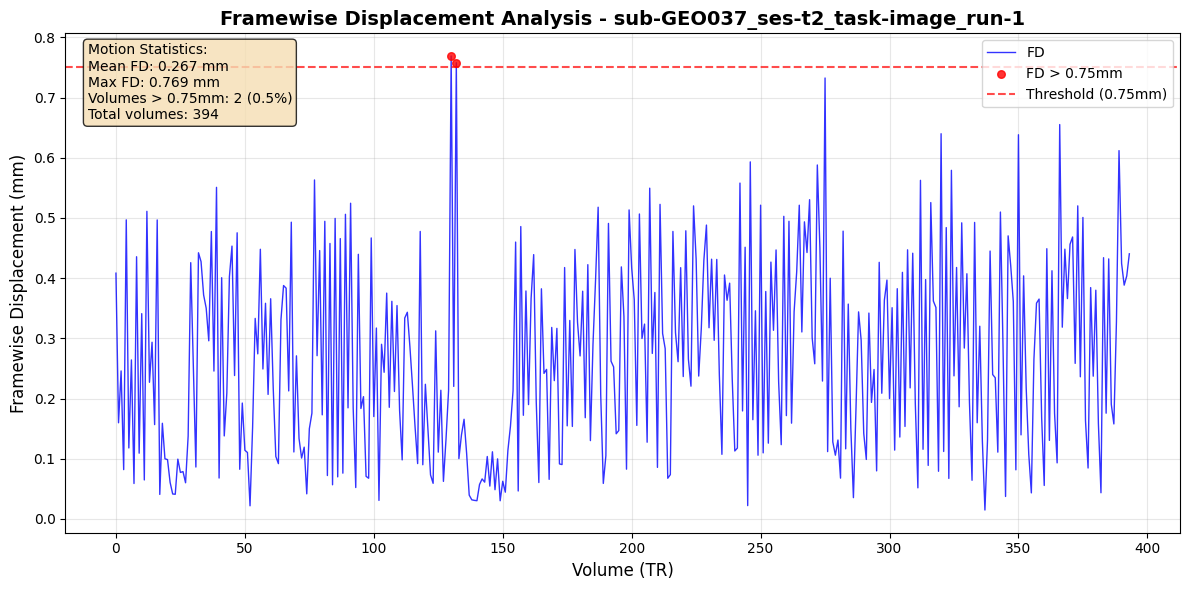

  Creating plot for: sub-GEO037_ses-t2_task-image_run-2


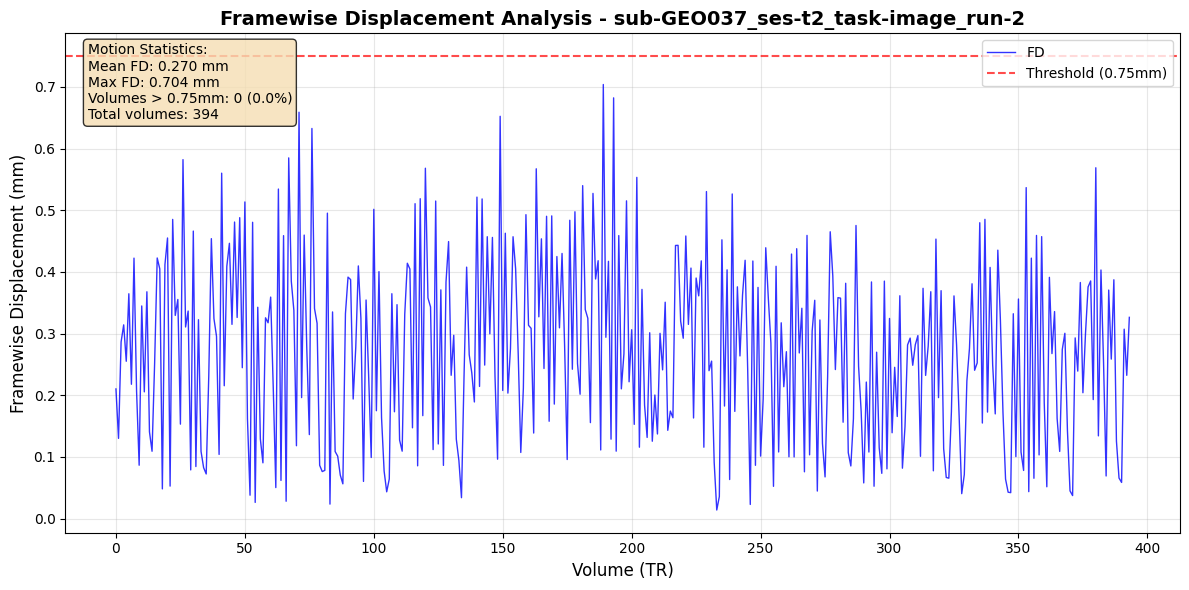

  Creating plot for: sub-GEO037_ses-t2_task-image_run-3


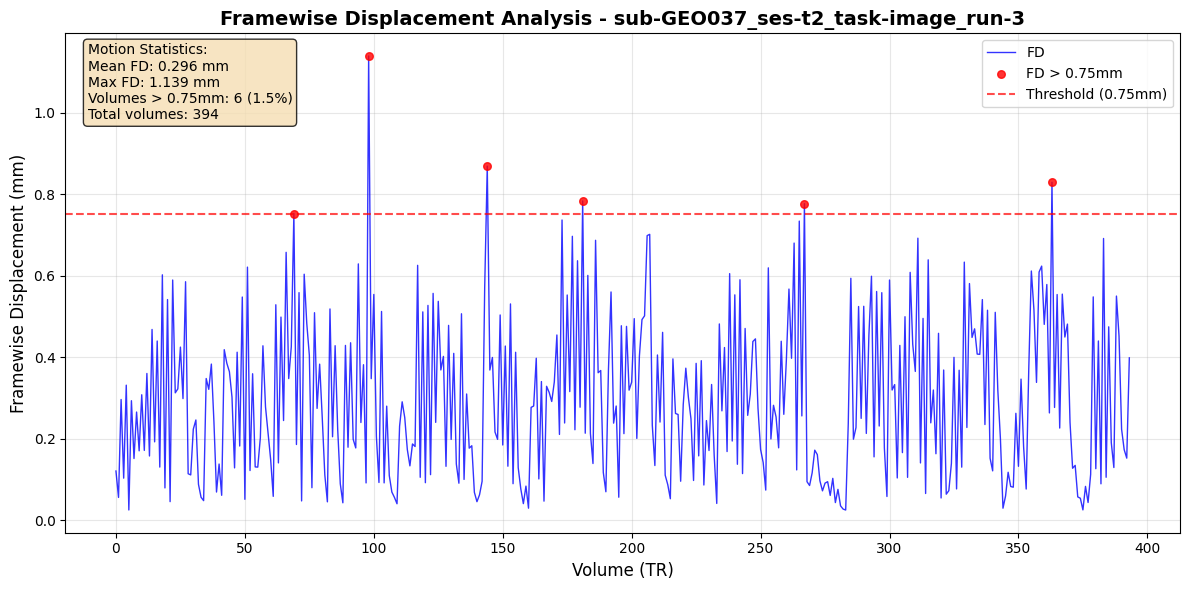

  Creating plot for: sub-GEO037_ses-t2_task-image_run-4


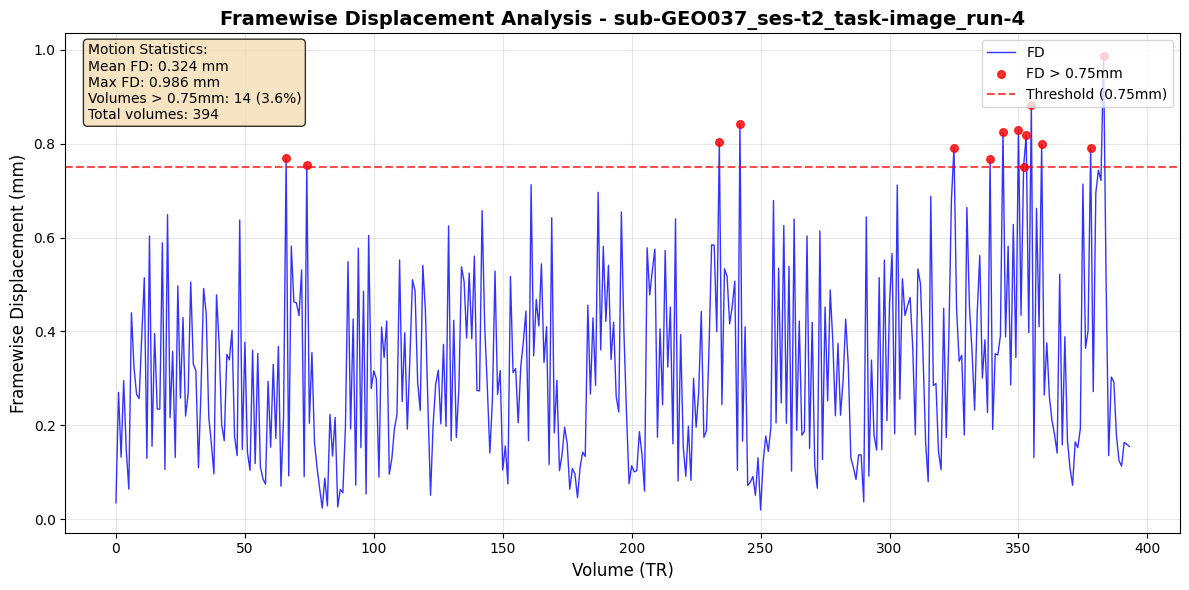

  Creating plot for: sub-GEO037_ses-t2_task-image_run-5


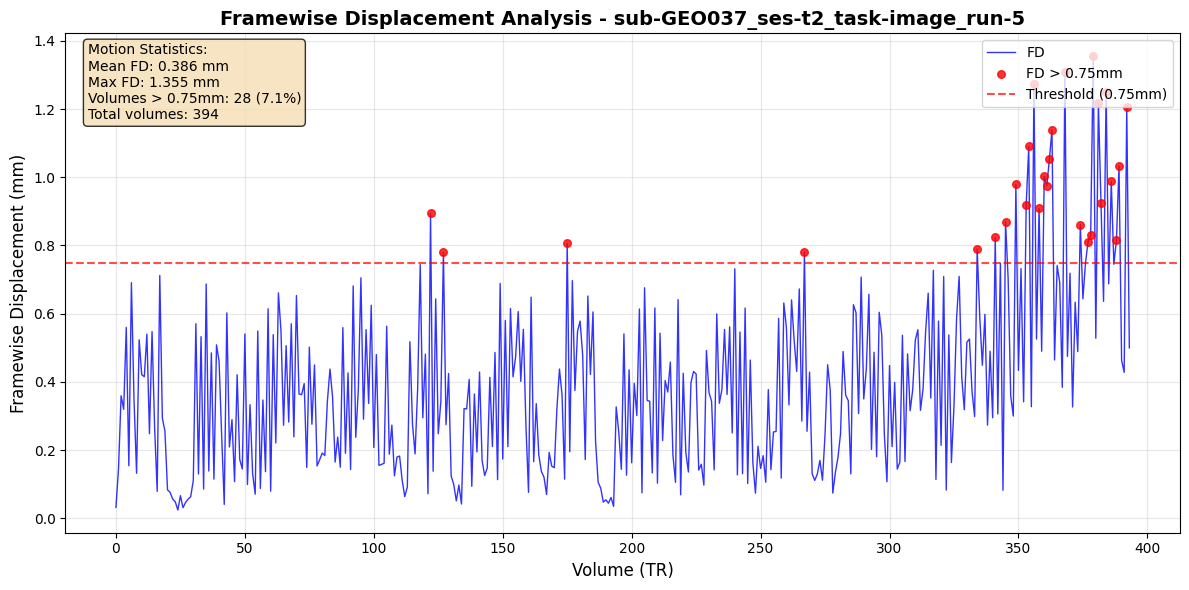

  Creating plot for: sub-GEO037_ses-t3_task-image_run-1


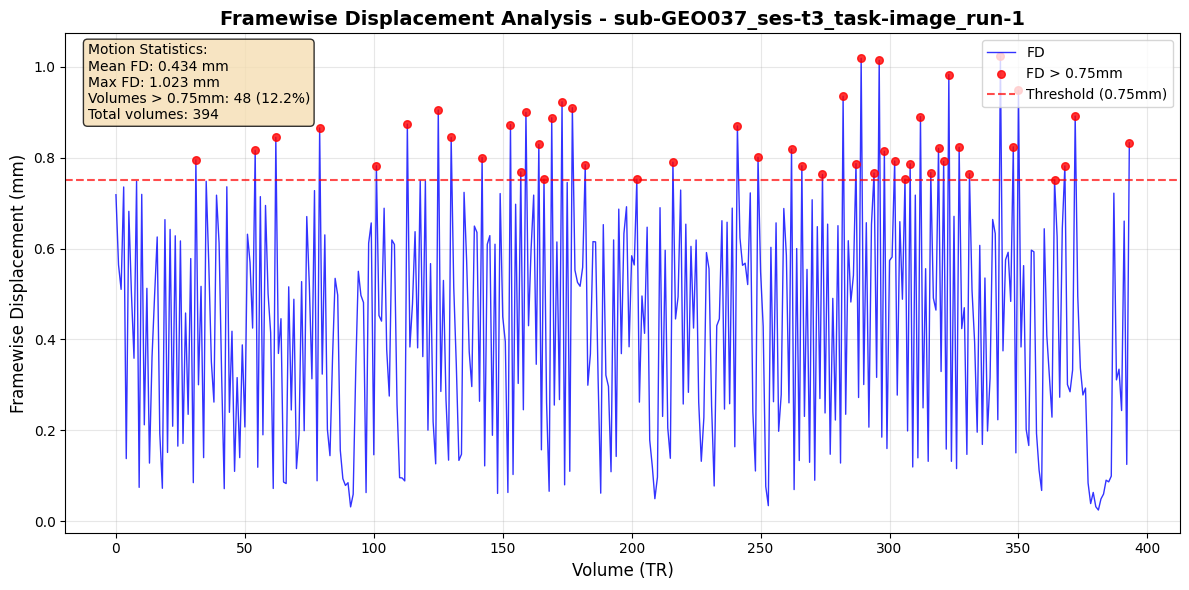

  Creating plot for: sub-GEO037_ses-t3_task-image_run-2


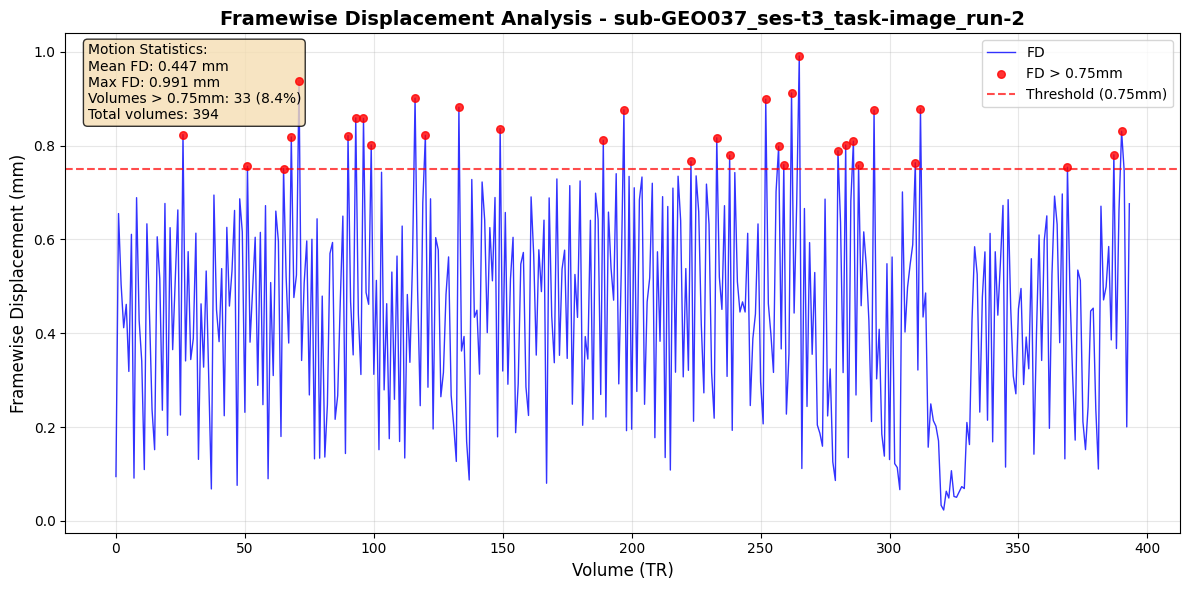

  Creating plot for: sub-GEO037_ses-t3_task-image_run-3


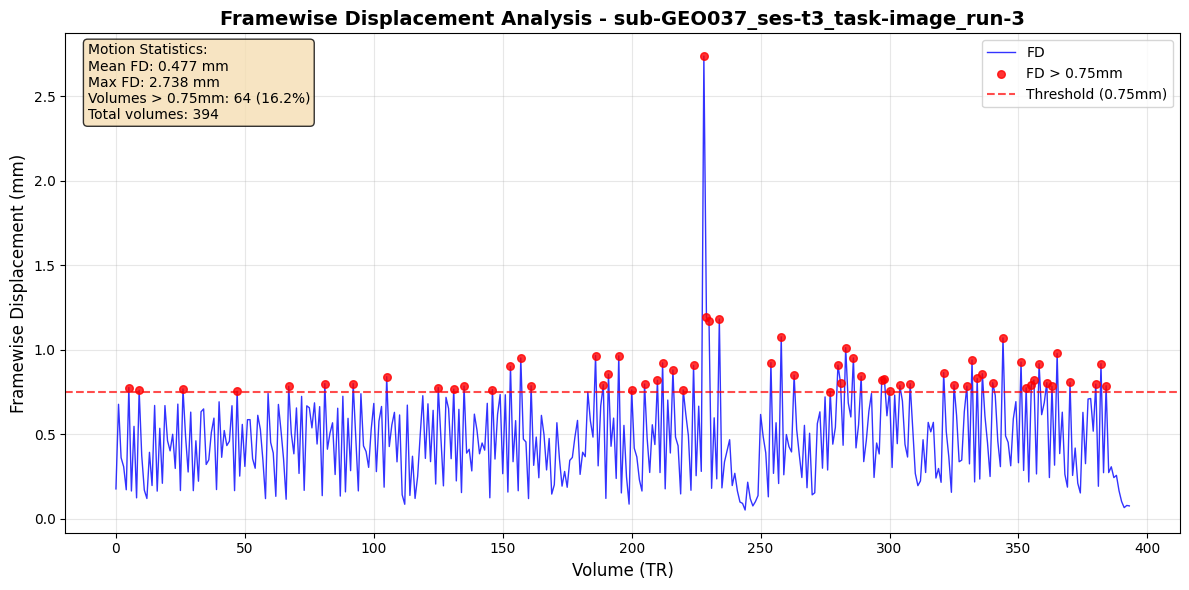

  Creating plot for: sub-GEO037_ses-t3_task-image_run-4


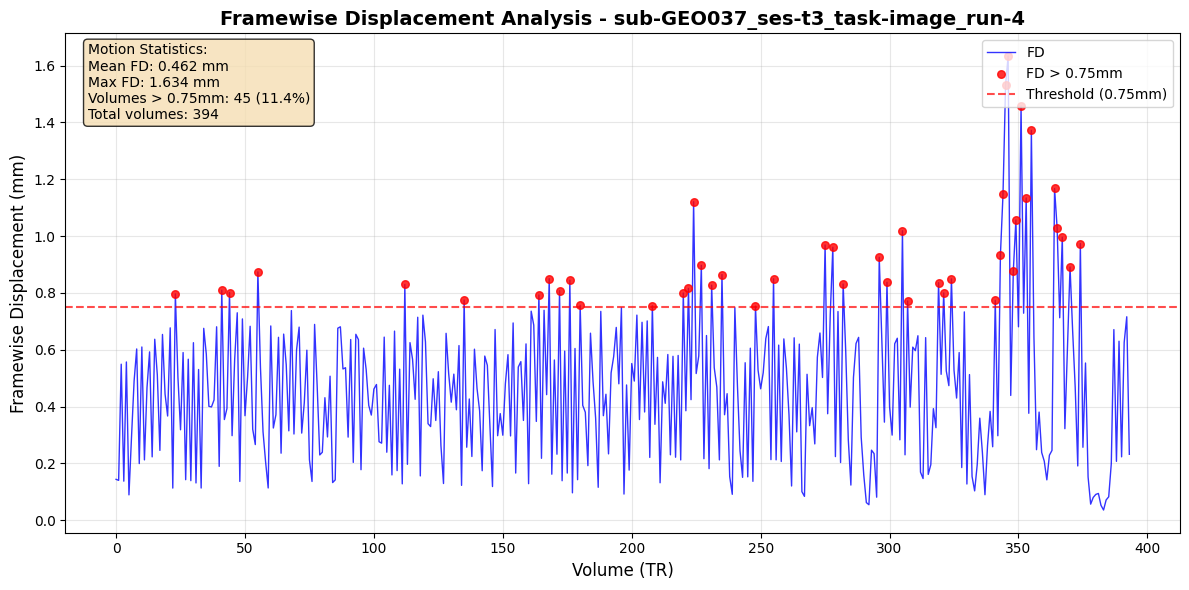

  Creating plot for: sub-GEO037_ses-t3_task-image_run-5


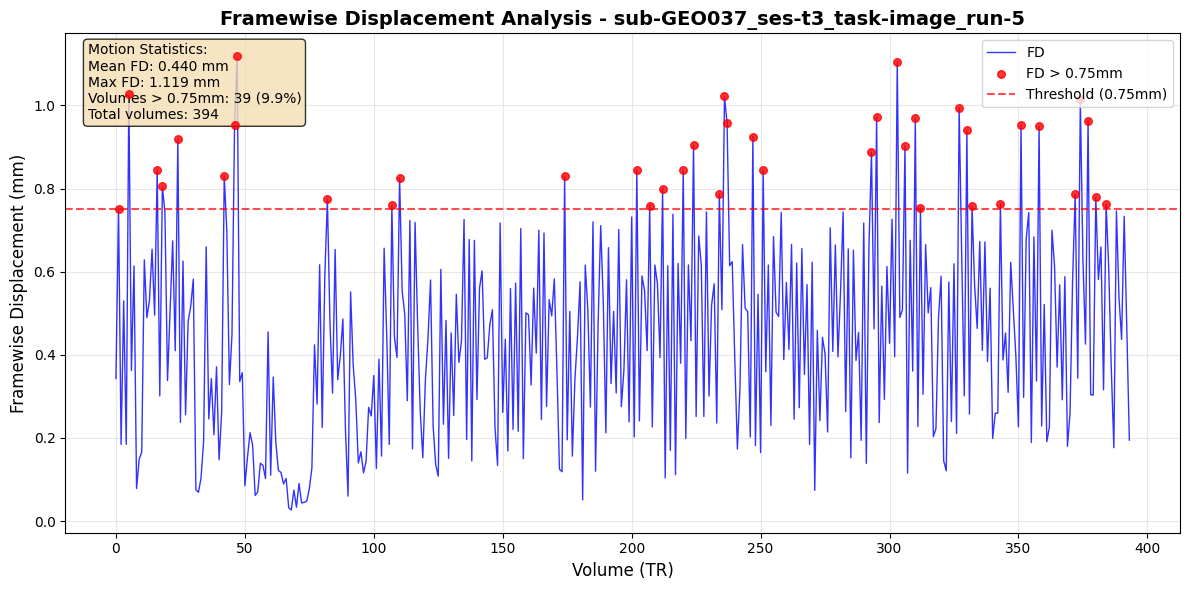

  Creating plot for: sub-GEO037_ses-t3_task-retrans_run-1


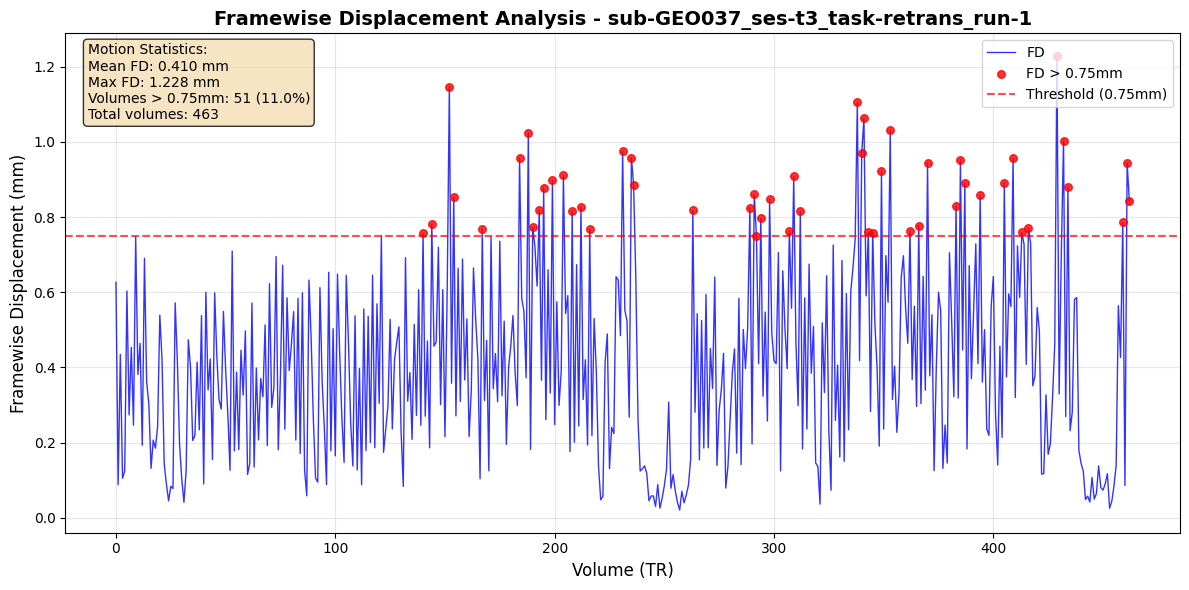


All plots created successfully!


In [16]:
def create_fd_plot(fd_results, run_key):
    """Create framewise displacement plot with threshold marking"""
    plt.style.use('default')  # Use default style for better compatibility
    fig, ax = plt.subplots(figsize=(PLOT_WIDTH, PLOT_HEIGHT))
    
    fd_data = fd_results['fd_data']
    high_motion_mask = fd_results['high_motion_mask']
    threshold = fd_results['fd_threshold']
    
    # Plot FD time series
    ax.plot(range(len(fd_data)), fd_data, 'b-', linewidth=1, alpha=0.8, label='FD')
    
    # Mark high motion volumes
    if high_motion_mask.any():
        high_motion_vols = np.where(high_motion_mask)[0]
        ax.scatter(high_motion_vols, fd_data.iloc[high_motion_vols], 
                  color='red', s=30, alpha=0.8, zorder=5, label=f'FD > {threshold}mm')
    
    # Add threshold line
    ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.7, 
               label=f'Threshold ({threshold}mm)')
    
    # Formatting
    ax.set_xlabel('Volume (TR)', fontsize=12)
    ax.set_ylabel('Framewise Displacement (mm)', fontsize=12)
    ax.set_title(f'Framewise Displacement Analysis - {run_key}', fontsize=14, fontweight='bold')
    
    # Add statistics text box
    stats_text = f"""Motion Statistics:
Mean FD: {fd_results['mean_fd']:.3f} mm
Max FD: {fd_results['max_fd']:.3f} mm
Volumes > {threshold}mm: {fd_results['n_high_motion']} ({fd_results['percentage_high_motion']:.1f}%)
Total volumes: {fd_results['total_volumes']}"""
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig

# Create plots for all runs
print("Creating FD visualization plots...")
print("=" * 50)

fd_plots = {}  # Store plot figures
fd_plots_base64 = {}  # Store base64 encoded plots for HTML

for subject_id, subject_results in fd_analysis_results.items():
    print(f"\nCreating plots for subject: {subject_id}")
    subject_plots = {}
    subject_plots_b64 = {}
    
    for run_key, results in subject_results.items():
        print(f"  Creating plot for: {run_key}")
        
        # Create plot
        fig = create_fd_plot(results, run_key)
        subject_plots[run_key] = fig
        
        # Convert to base64 for HTML embedding
        buffer = BytesIO()
        fig.savefig(buffer, format='png', dpi=PLOT_DPI, bbox_inches='tight')
        buffer.seek(0)
        plot_data = buffer.getvalue()
        buffer.close()
        
        plot_base64 = base64.b64encode(plot_data).decode()
        subject_plots_b64[run_key] = plot_base64
        
        # Display plot in notebook
        plt.show()
    
    fd_plots[subject_id] = subject_plots
    fd_plots_base64[subject_id] = subject_plots_b64

print("\nAll plots created successfully!")

## Save Results to HTML Reports

In [17]:
def create_fd_html_section(plot_base64, fd_results, run_key):
    """Create HTML section for FD analysis"""
    html_content = f"""
    <div class="fd-analysis-section" style="margin: 20px 0; border: 1px solid #ddd; border-radius: 8px; padding: 20px;">
        <h2 style="color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px;">
            Framewise Displacement Analysis - {run_key}
        </h2>
        
        <div class="fd-stats" style="background-color: #f8f9fa; padding: 15px; border-radius: 5px; margin: 15px 0;">
            <h3 style="color: #2c3e50; margin-top: 0;">Motion Summary</h3>
            <div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 10px;">
                <div><strong>Mean FD:</strong> {fd_results['mean_fd']:.3f} mm</div>
                <div><strong>Median FD:</strong> {fd_results['median_fd']:.3f} mm</div>
                <div><strong>Max FD:</strong> {fd_results['max_fd']:.3f} mm</div>
                <div><strong>Std FD:</strong> {fd_results['std_fd']:.3f} mm</div>
                <div><strong>High motion volumes:</strong> {fd_results['n_high_motion']} / {fd_results['total_volumes']}</div>
                <div><strong>Percentage > {fd_results['fd_threshold']}mm:</strong> {fd_results['percentage_high_motion']:.1f}%</div>
            </div>
            
            <div style="margin-top: 15px; padding: 10px; border-radius: 5px; font-weight: bold;
                        background-color: {'#d4edda' if fd_results['percentage_high_motion'] < 10 else '#fff3cd' if fd_results['percentage_high_motion'] < 20 else '#f8d7da'};
                        color: {'#155724' if fd_results['percentage_high_motion'] < 10 else '#856404' if fd_results['percentage_high_motion'] < 20 else '#721c24'};">
                Quality Assessment: {'GOOD' if fd_results['percentage_high_motion'] < 10 else 'MODERATE MOTION' if fd_results['percentage_high_motion'] < 20 else 'HIGH MOTION WARNING'}
            </div>
        </div>
        
        <div class="fd-plot" style="text-align: center; margin: 20px 0;">
            <img src="data:image/png;base64,{plot_base64}" 
                 style="max-width: 100%; height: auto; border: 1px solid #ddd; border-radius: 4px;">
        </div>
        
        <div style="font-size: 12px; color: #666; margin-top: 15px;">
            <strong>File:</strong> {fd_results['confounds_file'].name}<br>
            <strong>Generated:</strong> {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
        </div>
    </div>
    """
    return html_content

def add_fd_to_existing_html(html_file, fd_html_sections):
    """Add FD analysis to existing fMRIPrep HTML report"""
    try:
        with open(html_file, 'r', encoding='utf-8') as f:
            soup = BeautifulSoup(f, 'html.parser')
        
        # Add CSS for better styling
        style_tag = soup.new_tag('style')
        style_tag.string = """
        .fd-analysis-section { 
            font-family: Arial, sans-serif; 
            margin: 20px 0; 
        }
        .fd-analysis-section h2 { 
            color: #2c3e50; 
        }
        .fd-stats { 
            background-color: #f8f9fa; 
            padding: 15px; 
            border-radius: 5px; 
            margin: 15px 0; 
        }
        """
        if soup.head:
            soup.head.append(style_tag)
        
        # Insert FD sections
        for section_html in fd_html_sections:
            fd_div = BeautifulSoup(section_html, 'html.parser')
            
            # Find a good place to insert
            summary_section = soup.find('div', class_='summary')
            if summary_section:
                summary_section.insert_after(fd_div)
            else:
                body = soup.find('body')
                if body:
                    body.insert(0, fd_div)
        
        # Write modified HTML
        with open(html_file, 'w', encoding='utf-8') as f:
            f.write(str(soup))
        
        return True
    except Exception as e:
        print(f"Error modifying HTML file {html_file}: {e}")
        return False

def create_standalone_html_report(output_file, subject_id, fd_html_sections):
    """Create standalone HTML report for FD analysis"""
    html_template = f"""
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>FD Analysis Report - Subject {subject_id}</title>
        <style>
            body {{ 
                font-family: Arial, sans-serif; 
                margin: 40px; 
                background-color: #f5f5f5; 
            }}
            .container {{ 
                max-width: 1200px; 
                margin: 0 auto; 
                background-color: white; 
                padding: 30px; 
                border-radius: 10px; 
                box-shadow: 0 2px 10px rgba(0,0,0,0.1); 
            }}
            h1 {{ 
                color: #2c3e50; 
                text-align: center; 
                border-bottom: 3px solid #3498db; 
                padding-bottom: 15px; 
            }}
            .metadata {{ 
                background-color: #ecf0f1; 
                padding: 15px; 
                border-radius: 5px; 
                margin-bottom: 30px; 
            }}
        </style>
    </head>
    <body>
        <div class="container">
            <h1>Framewise Displacement Analysis Report</h1>
            
            <div class="metadata">
                <h2>Analysis Parameters</h2>
                <ul>
                    <li><strong>Subject:</strong> {subject_id}</li>
                    <li><strong>FD Threshold:</strong> {FD_LIMIT} mm</li>
                    <li><strong>Derivatives Type:</strong> {DERIVATIVES_TYPE}</li>
                    <li><strong>Generated:</strong> {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}</li>
                </ul>
            </div>
            
            {''.join(fd_html_sections)}
        </div>
    </body>
    </html>
    """
    
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html_template)

# Save results to HTML
print("Saving FD analysis to HTML reports...")
print("=" * 50)

html_reports_created = []

for subject_id, subject_results in fd_analysis_results.items():
    print(f"\nProcessing HTML reports for subject: {subject_id}")
    
    # Create HTML sections for all runs of this subject
    fd_html_sections = []
    
    for run_key, results in subject_results.items():
        plot_base64 = fd_plots_base64[subject_id][run_key]
        html_section = create_fd_html_section(plot_base64, results, run_key)
        fd_html_sections.append(html_section)
    
    # Look for existing fMRIPrep HTML reports
    fmriprep_dir = Path(DERIVATIVES_DIR) / 'fmriprep'
    html_pattern = f'sub-{subject_id}*.html'
    existing_html_files = list(fmriprep_dir.glob(html_pattern))
    
    if existing_html_files:
        # Add to existing HTML reports
        for html_file in existing_html_files:
            print(f"  Adding FD analysis to existing report: {html_file.name}")
            success = add_fd_to_existing_html(html_file, fd_html_sections)
            if success:
                html_reports_created.append(str(html_file))
                print(f"    ✅ Successfully updated: {html_file.name}")
            else:
                print(f"    ❌ Failed to update: {html_file.name}")
    
    # Always create standalone report as backup
    standalone_file = fmriprep_dir / f'sub-{subject_id}_FD_analysis_report.html'
    print(f"  Creating standalone report: {standalone_file.name}")
    create_standalone_html_report(standalone_file, subject_id, fd_html_sections)
    html_reports_created.append(str(standalone_file))
    print(f"    ✅ Created: {standalone_file.name}")

print("\n" + "=" * 50)
print("HTML Report Generation Complete!")
print(f"\nCreated/updated {len(html_reports_created)} HTML reports:")
for report in html_reports_created:
    print(f"  - {report}")

print(f"\n🎉 FD Analysis Complete!")
print(f"Processed {len(all_confounds_data)} subjects with FD threshold of {FD_LIMIT} mm")
print("Check the HTML reports for detailed QA information.")

Saving FD analysis to HTML reports...

Processing HTML reports for subject: GEO037
  Creating standalone report: sub-GEO037_FD_analysis_report.html


FileNotFoundError: [Errno 2] No such file or directory: '/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/fmriprep/sub-GEO037_FD_analysis_report.html'